In [1]:
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from torchvision import transforms
from torchvision.transforms.functional import to_tensor
import sys
from PIL import Image
import torch.optim as optim

In [2]:
class VideoDataset(Dataset):
    def __init__(self, data, temp_data_folder, NUM_FRAMES=10, transform_frame=None, label_map=None,transform_video=None, video_fps=25, resolution='1920:1080'):
        self.data = data  # It should be a list of tuples where data[0] is the path to the video and data[1] is the label

        self.transform_frame = transform_frame  # Transformations to be done on the individual frames.
                                                # Recommended to use when transforms is required at frames level with some randomness, eg: Random Crop
                                                # Note: If the Dataset is showing tensor issue, try adding `ToTensor()` in transform.

        self.transform_video = transform_video  # Transformations to be done on the whole video.
                                                # Recommended to use when transforms is required at video level with some randomness, eg: Random Horizontal Flip

        self.NUM_FRAMES = NUM_FRAMES  # Number of frames to be extracted from the video

        self.fps = video_fps  # The fps at which the video will be saved by ffmpeg
                              # Note: Reducing this might give a small performance increase, which might add up when running it multiple times. But this will also lead to
                              # loss of some data, as some frames will be dropped by ffmpeg
        self.label_map = label_map
        self.resolution = resolution  # resolution at which ffmpeg will save the frames (could be the same as the video or different).
                                      # Note: Reducing this might give a small performance increase, which might add up when running it multiple times.

        self.temp_data_folder = temp_data_folder  # A temporary folder where ffmpeg can store the frames of the video
                                                  # NOTE: this folder is recommended to be empty as frames get deleted from the folder after they are loaded as tensor!!


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        video_path = self.data[idx][0]
        video_file_name = os.path.basename(video_path)  # Assigns the name of the video to the variable
        output_video_path = os.path.join(self.temp_data_folder, video_file_name)  # creating a temp path in the temp_folder for saaving the frames of the video
        os.makedirs(output_video_path, exist_ok=True)  # Creating a folder with the name of the video in the temp_data_folder to save the frames of the video

        # Command to convert the video to frames
        fallback_cmd = [
                    'ffmpeg',
                    '-i', video_path,
                    '-vf', f'fps={self.fps},scale={self.resolution},format=yuv420p',
                    '-q:v', '2',
                    os.path.join(output_video_path, 'img_%05d.jpg')
        ]
        subprocess.run(fallback_cmd, check=True, stderr=subprocess.PIPE)

        video_frames = []

        video_images = sorted(os.listdir(output_video_path))

        frame_positions = np.linspace(0, len(video_images)-1, self.NUM_FRAMES, dtype=int)

        # Selecting the NUM_FRAMES from the video
        for n in frame_positions:
            img = video_images[int(n)]
            img_path = os.path.join(output_video_path, img)
            with Image.open(img_path) as pil_img:
                if self.transform_frame:
                    video_frames.append(self.transform_frame(pil_img))  # Note: Try adding ToTensor() in transform_frame, if any tensor related error arrises.
                    
                else:
                    video_frames.append(to_tensor(pil_img))

        try:
            video_frames = torch.stack(video_frames)  # Note: Try adding ToTensor() in transform_frame, if any tensor related error arrises.
            # video_frames = torch.stack(video_frames)   # (T, C, H, W)
            # video_frames = video_frames.mean(dim=0)   
        except TypeError:
            print(f"TypeError: Tried to stack {type(video_frames[0])}. Add ToTensor() in transform_frame!")
            sys.exit(1)
            return None, None


        if self.transform_video:
            video_frames = self.transform_video(video_frames)
        shutil.rmtree(output_video_path)  # Clean up temp folder

        label = self.data[idx][1]
        if self.label_map is not None:
            label = self.label_map[label]
        return video_frames, torch.tensor(label, dtype=torch.long)

In [3]:
df = pd.read_csv("train.csv")
data_tuple = list(zip(df.path, df.label))

In [4]:
label_map = {
    "geste_0": 0,
    "geste_1" :1,
    "geste_2": 2,
    "class_1": 3,
    "class_2": 4,
    "Gesture01":5,
    "Gesture02":6,
    "hand_turn":7,
    "ok_sign":8,
    "thumb_up":9
}

In [5]:
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomCrop((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness= 0.3, contrast =0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

val_transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std = (0.5, ))
])

In [6]:
dataset = VideoDataset(
    data=data_tuple,
    temp_data_folder="temp/",
    NUM_FRAMES=10,
    transform_frame=transform,
    label_map=label_map,
    video_fps=30,
    resolution="112:112"

)

batch_size= 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [7]:
val_df = pd.read_csv("val.csv")
val_data = list(zip(val_df.path, val_df.label))

val_dataset = VideoDataset(
    data=val_data,
    temp_data_folder='temp/',
    NUM_FRAMES=10,
    transform_frame=val_transform,
    label_map=label_map,
    video_fps=30,
    resolution='112:112'
)

batch_size = 32
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [8]:
# for video_frames, labels in dataloader:
#     print(labels)

In [9]:
class FrameCNN(nn.Module):
    """
    Lightweight CNN that maps a single RGB frame → feature vector.
    Global Average Pooling removes any dependency on input resolution.
    """
    def __init__(self, feature_dim: int = 128):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3 channels (RGB)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # H/2, W/2
            
            nn.Dropout2d(0.1),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # H/4, W/4
 
            nn.Dropout2d(0.2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # H/8, W/8
 
            nn.Dropout2d(0.3),
            # Block 4
            nn.Conv2d(128, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(inplace=True),
        )
        # Global Average Pooling → output is always (B, feature_dim)
        # regardless of spatial input size.
        self.gap = nn.AdaptiveAvgPool2d(1)
 
    def forward(self, x):
        # x: (B, C, H, W)
        x = self.features(x)   # (B, feature_dim, h, w)
        x = self.gap(x)        # (B, feature_dim, 1, 1)
        x = x.flatten(1)       # (B, feature_dim)
        return x
 
 
class VideoClassifier_old(nn.Module):
    """
    Processes each frame independently with a shared CNN,
    then aggregates frame features via mean-pooling and classifies.
 
    Input shape : (B, T, C, H, W)
    Output shape: (B, num_classes)
    """
    def __init__(self, num_classes: int = 14, feature_dim: int = 128):
        super().__init__()
        self.frame_cnn = FrameCNN(feature_dim=feature_dim)
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )
 
    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
 
        # Merge batch and time dims so we process all frames at once
        x = x.view(B * T, C, H, W)          # (B*T, C, H, W)
        feats = self.frame_cnn(x)            # (B*T, feature_dim)
        feats = feats.view(B, T, -1)         # (B, T, feature_dim)
 
        # Temporal aggregation: simple mean pooling across frames
        feats = feats.mean(dim=1)            # (B, feature_dim)
 
        return self.classifier(feats)        # (B, num_classes)

class VideoClassifier(nn.Module):
    def __init__(self, num_classes=3, feature_dim=128, hidden_dim=64, num_layers=1):
        super().__init__()
        self.frame_cnn = FrameCNN(feature_dim=feature_dim)
        self.gru = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feats = self.frame_cnn(x)            # (B*T, feature_dim)
        feats = feats.view(B, T, -1)         # (B, T, feature_dim)  ← sequence preserved!
        out, _ = self.gru(feats)             # h_n: (num_layers, B, hidden_dim)
        out = out[:,-1, :]                        # (B, hidden_dim) — last hidden state
        return self.classifier(out)


In [ ]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights


class PretrainedVideoClassifier(nn.Module):
    """
    Option B: Pretrained MobileNetV3-Small backbone (ImageNet weights) +
    Bidirectional LSTM classifier.

    The backbone already understands edges, textures, and shapes — far more
    useful than training from scratch on 228 samples. Backbone weights are
    frozen by default so only the LSTM + head are updated, which prevents
    overfitting on the small dataset.

    Input shape : (B, T, C, H, W)  — same interface as VideoClassifier
    Output shape: (B, num_classes)
    """
    def __init__(self, num_classes: int = 10, hidden_dim: int = 128,
                 num_layers: int = 2, freeze_backbone: bool = True):
        super().__init__()

        backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        # Drop the classification head; keep only the conv feature extractor
        self.feature_extractor = backbone.features   # outputs (B, 576, h, w)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        feature_dim = 576  # MobileNetV3-Small final channel count

        if freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes),  # *2 for bidirectional
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)                          # merge batch & time
        feats = self.avgpool(self.feature_extractor(x))      # (B*T, 576, 1, 1)
        feats = feats.flatten(1)                             # (B*T, 576)
        feats = feats.view(B, T, -1)                         # (B, T, 576)
        out, _ = self.lstm(feats)                            # (B, T, hidden*2)
        return self.classifier(out[:, -1, :])                # last timestep


# ── ImageNet-normalised transforms (required for pretrained backbone) ──────────
# Use these instead of transform/val_transform when training PretrainedVideoClassifier.
imagenet_train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet mean
                         std=[0.229, 0.224, 0.225]),   # ImageNet std
])

imagenet_val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# ── Rebuild dataloaders with ImageNet normalisation ────────────────────────────
pretrained_dataset = VideoDataset(
    data=data_tuple,
    temp_data_folder="temp/",
    NUM_FRAMES=16,                           # more frames → richer temporal signal
    transform_frame=imagenet_train_transform,
    label_map=label_map,
    video_fps=30,
    resolution="128:128",
)
pretrained_dataloader = DataLoader(pretrained_dataset, batch_size=16, shuffle=True)

pretrained_val_dataset = VideoDataset(
    data=val_data,
    temp_data_folder="temp/",
    NUM_FRAMES=16,
    transform_frame=imagenet_val_transform,
    label_map=label_map,
    video_fps=30,
    resolution="128:128",
)
pretrained_val_dataloader = DataLoader(pretrained_val_dataset, batch_size=16, shuffle=False)


# ── Model, optimiser, scheduler ───────────────────────────────────────────────
# Only LSTM + classifier params are trained while the backbone is frozen.
# After epoch 20 the last backbone block is automatically unfrozen at lr=1e-5.
device = "cuda"
pretrained_model = PretrainedVideoClassifier(
    num_classes=10,
    hidden_dim=128,
    num_layers=2,
    freeze_backbone=True,
).to(device)

pretrained_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
pretrained_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    pretrained_optimizer, T_max=50
)
pretrained_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


# ── Training loop ─────────────────────────────────────────────────────────────
best_val_acc_pretrained = 0.0
pretrained_train_accs, pretrained_val_accs = [], []

for epoch in range(1, 51):
    pretrained_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for videos, labels in pretrained_dataloader:
        videos, labels = videos.to(device), labels.to(device)
        pretrained_optimizer.zero_grad(set_to_none=True)
        outputs = pretrained_model(videos)
        loss = pretrained_criterion(outputs, labels)
        loss.backward()
        pretrained_optimizer.step()

        train_loss    += loss.item() * videos.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += videos.size(0)

    pretrained_scheduler.step()

    # ── Unfreeze last backbone block at epoch 20 for gradual fine-tuning ───
    if epoch == 20:
        last_block = list(pretrained_model.feature_extractor.children())[-1]
        for param in last_block.parameters():
            param.requires_grad = True
        pretrained_optimizer.add_param_group({"params": last_block.parameters(), "lr": 1e-5})
        print("Epoch 20: unfroze last backbone block for fine-tuning")

    pretrained_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for videos, labels in pretrained_val_dataloader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = pretrained_model(videos)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc = train_correct / train_total
    val_acc   = val_correct / val_total * 100
    pretrained_train_accs.append(train_acc * 100)
    pretrained_val_accs.append(val_acc)

    if val_acc > best_val_acc_pretrained:
        best_val_acc_pretrained = val_acc
        torch.save(pretrained_model.state_dict(), "model_pretrained_best.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train acc: {train_acc*100:.1f}%  "
              f"val acc: {val_acc:.1f}%  (best: {best_val_acc_pretrained:.1f}%)")


In [10]:
device = "cuda"
model = VideoClassifier(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
train_accs = []
val_accs = []
for epoch in range(1, 50 + 1):
    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for videos, labels in dataloader:
        # videos : (B, T, C, H, W)
        # labels : (B,)
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(videos)                    # (B, num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * videos.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += videos.size(0)

    scheduler.step()
    avg_train_loss = train_loss / train_total
    train_acc      = train_correct / train_total
    train_accs.append(train_acc)
    # validate
    model.eval()

    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for videos, labels in val_dataloader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)                    # (B, num_classes)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * videos.size(0)
            preds = outputs.argmax(dim=1)
            # _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    avg_loss = val_loss / val_total

    accuracy = (val_correct / val_total)*100
    val_accs.append(accuracy)

    if epoch%10 == 0:
        print(f"Epoch : {epoch}")
        print(f"Average train loss: {avg_train_loss} \nTrain  Accuracy : {train_acc}") 
        print("----------------------------------------------------------------------")   
        print(f"Average loss: {avg_loss} \n Accuracy : {accuracy}")


Epoch : 10
Average train loss: 1.016766857682613 
Train  Accuracy : 0.5657894736842105
----------------------------------------------------------------------
Average loss: 0.9515428041156969 
 Accuracy : 50.0
Epoch : 20
Average train loss: 0.8823274729544657 
Train  Accuracy : 0.5657894736842105
----------------------------------------------------------------------
Average loss: 0.8686460538914329 
 Accuracy : 51.31578947368421
Epoch : 30
Average train loss: 0.7660254470089025 
Train  Accuracy : 0.6710526315789473
----------------------------------------------------------------------
Average loss: 0.8610251859614724 
 Accuracy : 55.26315789473685
Epoch : 40
Average train loss: 0.7905175246690449 
Train  Accuracy : 0.6666666666666666
----------------------------------------------------------------------
Average loss: 0.8409060647613124 
 Accuracy : 53.94736842105263
Epoch : 50
Average train loss: 0.7630926203309444 
Train  Accuracy : 0.6754385964912281
----------------------------------

In [11]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [12]:
torch.save(model.state_dict(), "model4.pth")

In [13]:
test_df = pd.read_csv("test.csv")
test_data = list(zip(test_df.path, test_df.label))

test_dataset = VideoDataset(
    data=test_data,
    temp_data_folder='temp/',
    NUM_FRAMES=10,
    transform_frame=val_transform,
    label_map=label_map,
    video_fps=30,
    resolution='112:112'
)

batch_size = 32
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [14]:
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for videos, labels in test_dataloader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)                    # (B, num_classes)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * videos.size(0)
        preds = outputs.argmax(dim=1)
        # _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

avg_loss = test_loss / test_total

accuracy = (test_correct / test_total)*100

print(accuracy)

57.14285714285714


In [15]:
print(val_accs)

[10.526315789473683, 31.57894736842105, 34.21052631578947, 27.631578947368425, 38.15789473684211, 43.42105263157895, 55.26315789473685, 50.0, 46.05263157894737, 50.0, 53.94736842105263, 55.26315789473685, 47.368421052631575, 52.63157894736842, 55.26315789473685, 57.89473684210527, 48.68421052631579, 48.68421052631579, 50.0, 51.31578947368421, 56.57894736842105, 56.57894736842105, 55.26315789473685, 53.94736842105263, 53.94736842105263, 53.94736842105263, 55.26315789473685, 55.26315789473685, 53.94736842105263, 55.26315789473685, 53.94736842105263, 55.26315789473685, 53.94736842105263, 56.57894736842105, 56.57894736842105, 55.26315789473685, 52.63157894736842, 53.94736842105263, 55.26315789473685, 53.94736842105263, 52.63157894736842, 52.63157894736842, 53.94736842105263, 59.210526315789465, 56.57894736842105, 56.57894736842105, 53.94736842105263, 51.31578947368421, 56.57894736842105, 53.94736842105263]


In [16]:
print(train_accs)

[0.21052631578947367, 0.27631578947368424, 0.3684210526315789, 0.4605263157894737, 0.4868421052631579, 0.4956140350877193, 0.5614035087719298, 0.543859649122807, 0.5789473684210527, 0.5657894736842105, 0.5614035087719298, 0.5745614035087719, 0.5921052631578947, 0.5921052631578947, 0.5745614035087719, 0.5964912280701754, 0.5789473684210527, 0.6754385964912281, 0.6622807017543859, 0.5657894736842105, 0.5964912280701754, 0.5789473684210527, 0.6140350877192983, 0.6271929824561403, 0.6447368421052632, 0.6447368421052632, 0.631578947368421, 0.6271929824561403, 0.6008771929824561, 0.6710526315789473, 0.6578947368421053, 0.6271929824561403, 0.6491228070175439, 0.5833333333333334, 0.5789473684210527, 0.6447368421052632, 0.6929824561403509, 0.6491228070175439, 0.6710526315789473, 0.6666666666666666, 0.6622807017543859, 0.6228070175438597, 0.6491228070175439, 0.6447368421052632, 0.6885964912280702, 0.6578947368421053, 0.6228070175438597, 0.6491228070175439, 0.6710526315789473, 0.6754385964912281]

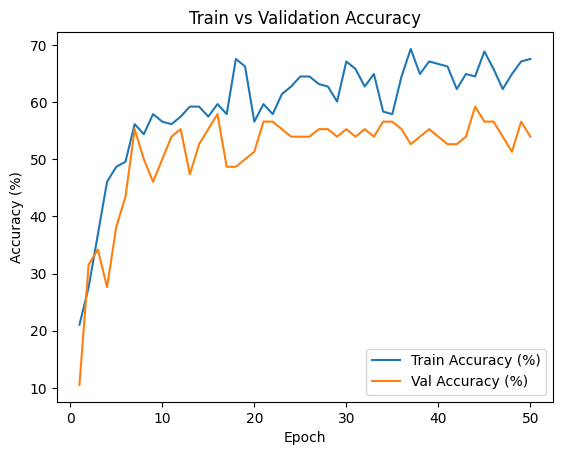

In [17]:
train_accs_pct = [acc * 100 for acc in train_accs]  # convert to %

fig, ax = plt.subplots()
ax.plot(range(1, len(train_accs_pct) + 1), train_accs_pct, label="Train Accuracy (%)")
ax.plot(range(1, len(val_accs) + 1), val_accs, label="Val Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Validation Accuracy")
ax.legend()
plt.show()
